In [1]:
from preprocessing import *
from loading_data_for_training import *
import numpy as np
import os
import pandas as pd
from autogluon.timeseries import TimeSeriesPredictor, TimeSeriesDataFrame
from autogluon_validation_scripts import *
from autogluon_forecast_plot import *

c:\Users\rogal\anaconda3\envs\autogluon_new\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

df_combined = load_all_data_alpaca()
df_combined.head(2)

,close,high,low,n,open,timestamp,volume,vw,ticker,high-low,...,Direction_change_3d,Direction_5d,Trend_strength_5d,Direction_change_5d,Direction_10d,Trend_strength_10d,Direction_change_10d,Direction_20d,Trend_strength_20d,Direction_change_20d
0,141.81,142.425,138.815,9990,140.85,2023-01-25,1154572,140.837719,AAPL,3.61,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.4,0.0
1,143.94,144.250,141.930,10016,143.22,2023-01-26,1030855,143.316486,AAPL,2.32,...,0.0,1.0,1.0,0.0,1.0,1.0,0.0,1.0,0.3,0.0


In [9]:
# Sprawdzenie liczby rekordów dla każdego tickeru
counts = df_combined.groupby('ticker').size()
print(counts)

ticker
AAPL     783
AMZN     783
GOOGL    783
JPM      783
META     783
MSFT     783
NVDA     783
TSLA     783
V        783
dtype: int64


## Train and save autogluon models

In [4]:
def train_models(df_final, target, period, metric, path):
    '''
        Training autogluon models to predict the target. Saves models in the specified directory
    '''

    # Create dataframe in Autogluon format
    ts_data = TimeSeriesDataFrame.from_data_frame(
        df_final,
        id_column="ticker",
        timestamp_column="timestamp"
    )

    num_test_windows = 20
    prediction_length = period
    total_backtest_size = num_test_windows * prediction_length

    train_data, test_data = ts_data.train_test_split(total_backtest_size)
    print("Train data size: ", len(train_data))
    print("Test data size: ", len(test_data))

    predictor = TimeSeriesPredictor(
    prediction_length=period,
    path=path,
    target=target,

    quantile_levels=[0.05,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95],
    eval_metric=metric,
        freq='B'
    )
    predictor.fit(
        train_data,
        presets="high_quality",
        hyperparameters = {
        "DeepAR": {"context_length": 100, "num_layers": 3, "regression_full_covariance": True, "likelihood": "student-t"},
        "RecursiveTabular":{},
        "TemporalFusionTransformer": {"context_length": 120},
        "PatchTST": {"context_length": 252},
        "AutoETS": {},      # Modele statystyczne
        "Theta": {},
        "Chronos2":{}
        },
        time_limit=36000
    )

    return predictor, test_data

## Train models

In [ ]:
#predictor, test_data = train_models(df_combined, "Return_1d", 5, "RMSE", "gluon_models")

Beginning AutoGluon training... Time limit = 36000s
AutoGluon will save models to 'c:\Users\rogal\MojGithub\Stock-Market-Forecasting\autogluon_modeling\gluon_models'


Train data size:  6147
Test data size:  7047


=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.10.19
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
GPU Memory:         
Total GPU Memory:   Free: 0.00 GB, Allocated: 0.00 GB, Total: 0.00 GB
GPU Count:          0
Memory Avail:       4.47 GB / 15.74 GB (28.4%)
Disk Space Avail:   73.71 GB / 457.28 GB (16.1%)
Setting presets to: high_quality

Fitting with arguments:
{'enable_ensemble': True,
 'eval_metric': RMSE,
 'freq': 'B',
 'hyperparameters': {'AutoETS': {},
                     'Chronos2': {},
                     'DeepAR': {'context_length': 100,
                                'likelihood': 'student-t',
                                'num_layers': 3,
                                'regression_full_covariance': True},
                     'PatchTST': {'context_length': 252},
                     'R

In [3]:
ts_data = TimeSeriesDataFrame.from_data_frame(
        df_combined,
        id_column="ticker",
        timestamp_column="timestamp"
    )

num_test_windows = 20
prediction_length = 5
total_backtest_size = num_test_windows * prediction_length

train_data, test_data = ts_data.train_test_split(total_backtest_size)

predictor = TimeSeriesPredictor.load("gluon_models")

In [6]:
summarize_results_all_windows(predictor, test_data)

data with frequency 'IRREG' has been resampled to frequency 'B'.


------------------------------------------------Starting to summarize results------------------------------------
Calculating results for:  AAPL


data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRRE

Calculating results for:  AMZN


data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRRE

...

Calculating results for:  TSLA


data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRRE

Calculating results for:  V


data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRREG' has been resampled to frequency 'B'.
data with frequency 'IRRE

        Mean_MASE  Mean_RMSE  Mean WQL
Ticker                                
AAPL     0.581522   0.012522  0.829064
AMZN     0.753115   0.018561  0.846670
GOOGL    0.668925   0.016315  0.939363
JPM      0.831295   0.015071  0.748718
META     0.696330   0.019966  0.787274
MSFT     0.887338   0.015770  0.854241
NVDA     0.539978   0.022167  0.738739
TSLA     0.505871   0.024909  0.876626
V        0.843436   0.012443  0.859226


In [7]:
mean_hit_ratio_all_windows(predictor, "Return_1d", test_data, 5)

data with frequency 'IRREG' has been resampled to frequency 'B'.


------------------------------------------Strting to calculate hit ratios---------------------------------------
Hit ratio for :  AAPL
Hit ratio for :  AMZN
Hit ratio for :  GOOGL
Hit ratio for :  JPM
Hit ratio for :  META
Hit ratio for :  MSFT
Hit ratio for :  NVDA
Hit ratio for :  TSLA
Hit ratio for :  V
        Hit Ratio
Ticker           
TSLA         0.61
MSFT         0.60
V            0.55
JPM          0.54
GOOGL        0.54
NVDA         0.54
AAPL         0.53
AMZN         0.52
META         0.48


In [6]:
calculate_coverage_winkler(predictor, test_data, "Return_1d")


data with frequency 'IRREG' has been resampled to frequency 'B'.


Coverage : 
   Coverage Actual (0.05)  Coverage Error (0.05)  Coverage Actual (0.1)  \
0                0.080702               0.030702               0.132164   

   Coverage Error (0.1)  Coverage Actual (0.3)  Coverage Error (0.3)  \
0              0.032164               0.295906             -0.004094   

   Coverage Actual (0.9)  Coverage Error (0.9)  
0               0.892398             -0.007602  
Winkler:
         Winkler Score (0.1-0.9)  Winkler Normalized
item_id                                             
AAPL                    0.050569            3.144211
AMZN                    0.076745            3.863122
GOOGL                   0.066200            3.525480
JPM                     0.060659            4.105429
META                    0.083432            3.460454
MSFT                    0.066237            4.403572
NVDA                    0.091930            2.054315
TSLA                    0.115747            3.119498
V                       0.049580            4.135238


data with frequency 'IRREG' has been resampled to frequency 'B'.


------------------------------------Starting to plot backtest------------------------


data with frequency 'IRREG' has been resampled to frequency 'B'.


Plotting backtest ticker:  AAPL


data with frequency 'IRREG' has been resampled to frequency 'B'.


...

data with frequency 'IRREG' has been resampled to frequency 'B'.


Plotting backtest ticker:  TSLA


data with frequency 'IRREG' has been resampled to frequency 'B'.


Plotting backtest ticker:  V


<Figure size 1000x500 with 0 Axes>

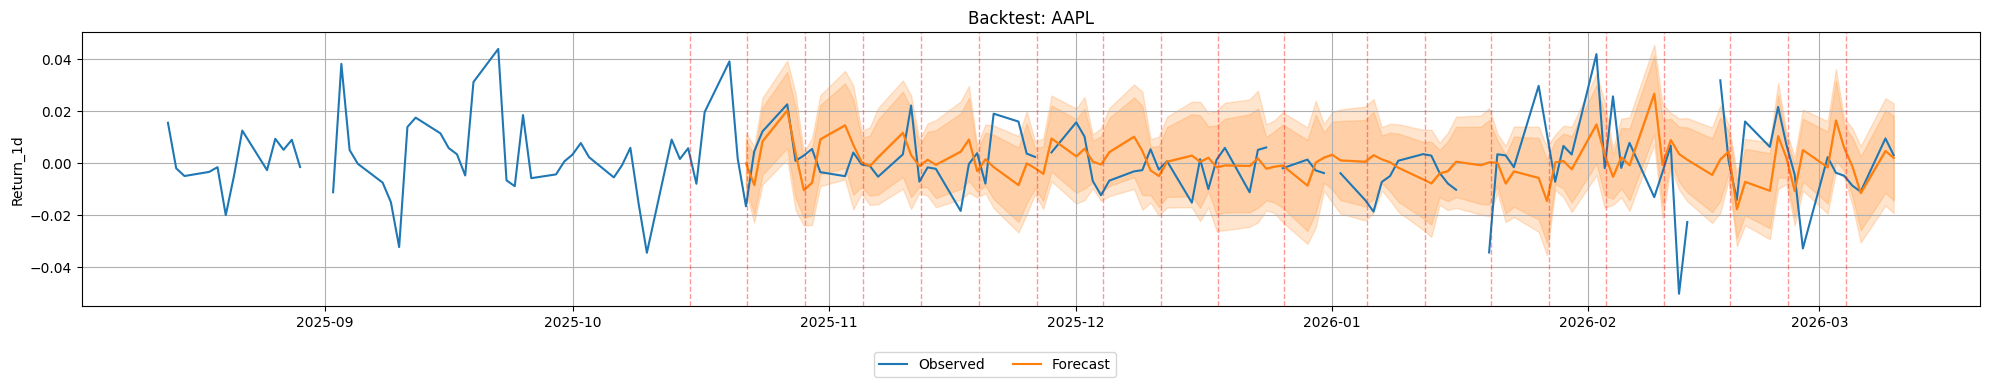

<Figure size 1000x500 with 0 Axes>

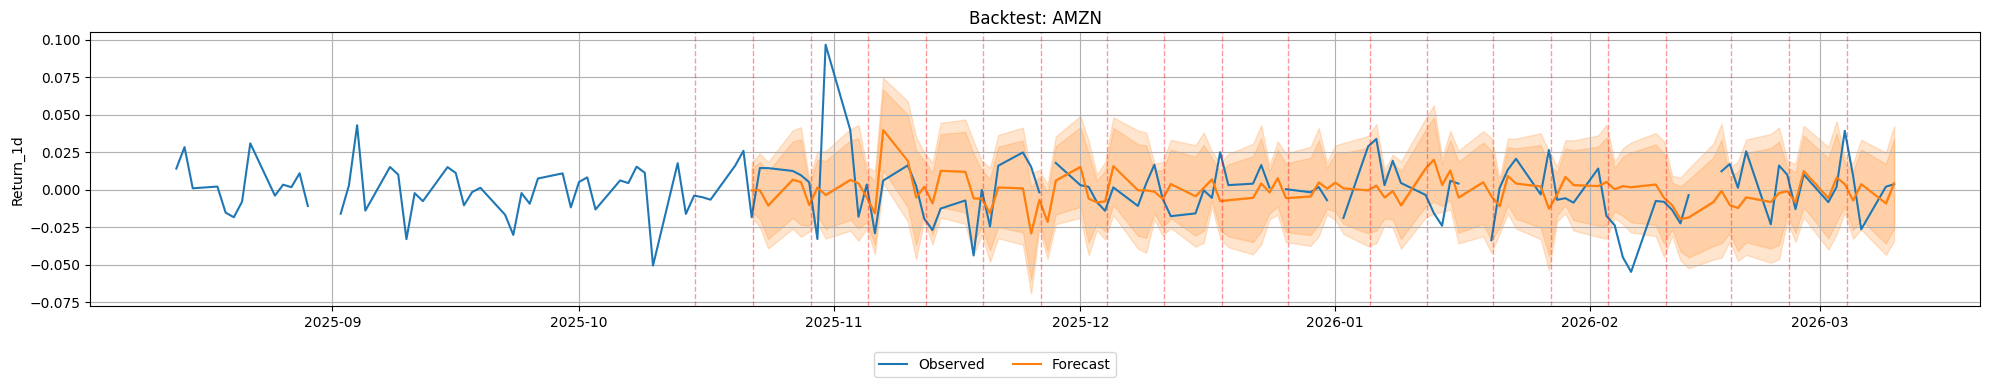

<Figure size 1000x500 with 0 Axes>

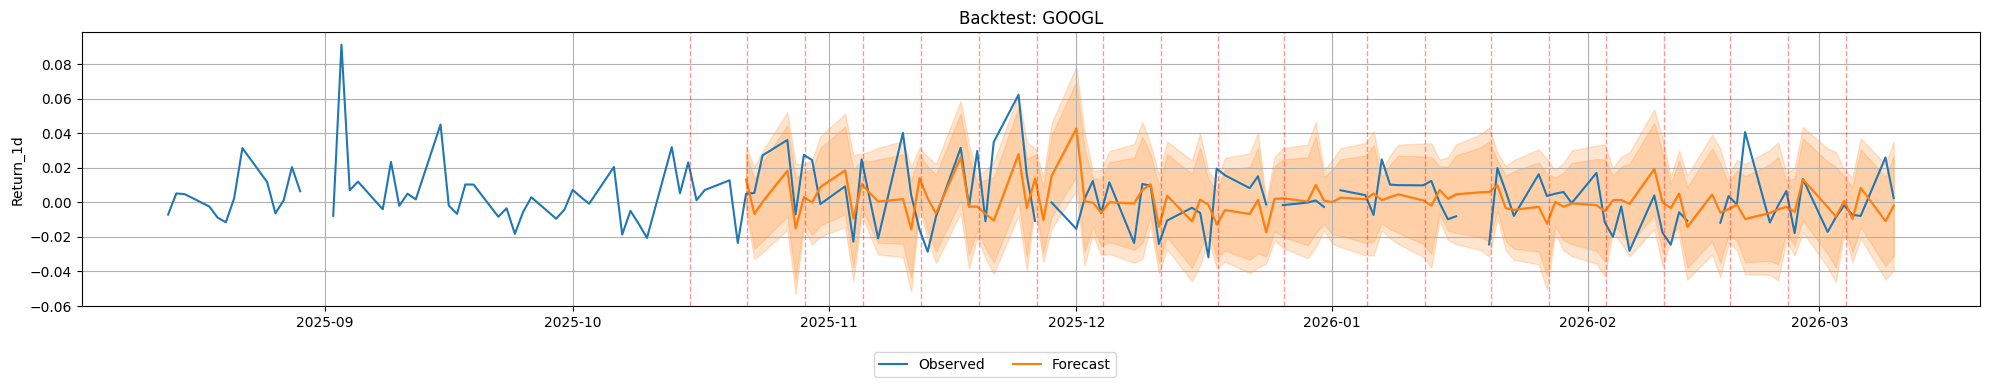

<Figure size 1000x500 with 0 Axes>

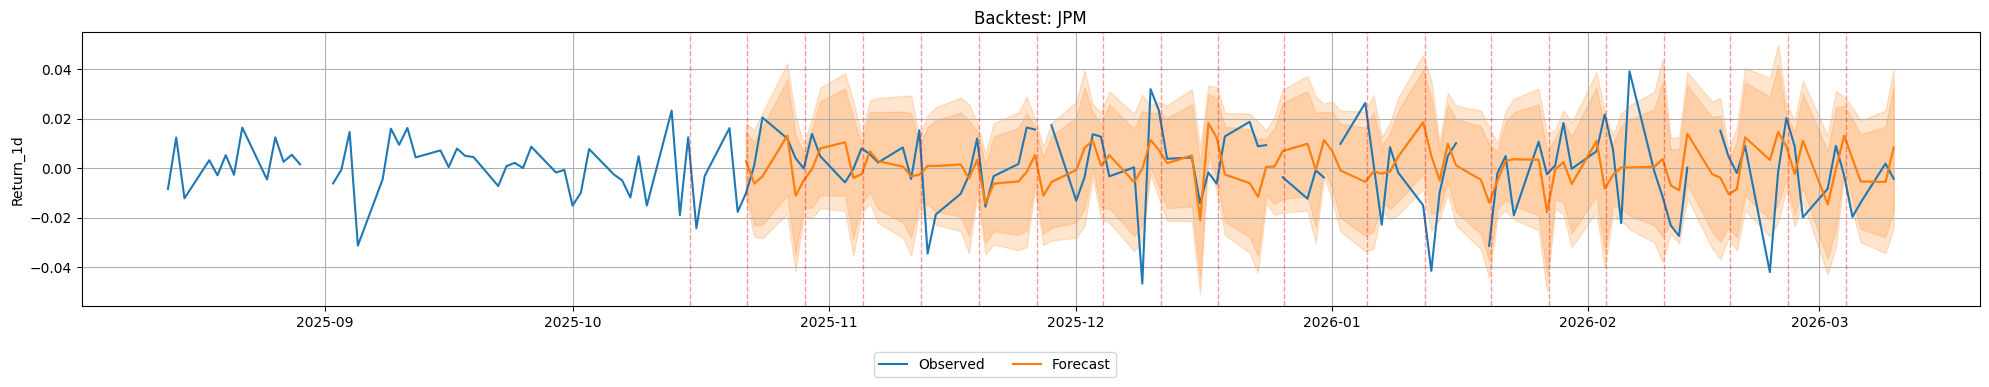

<Figure size 1000x500 with 0 Axes>

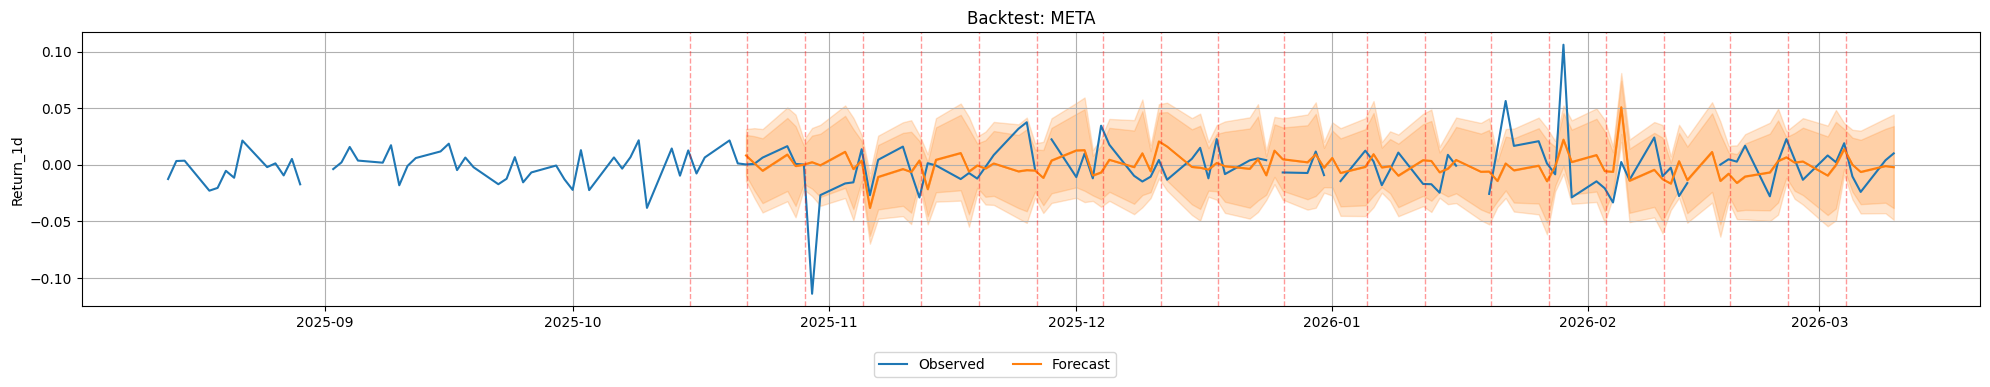

<Figure size 1000x500 with 0 Axes>

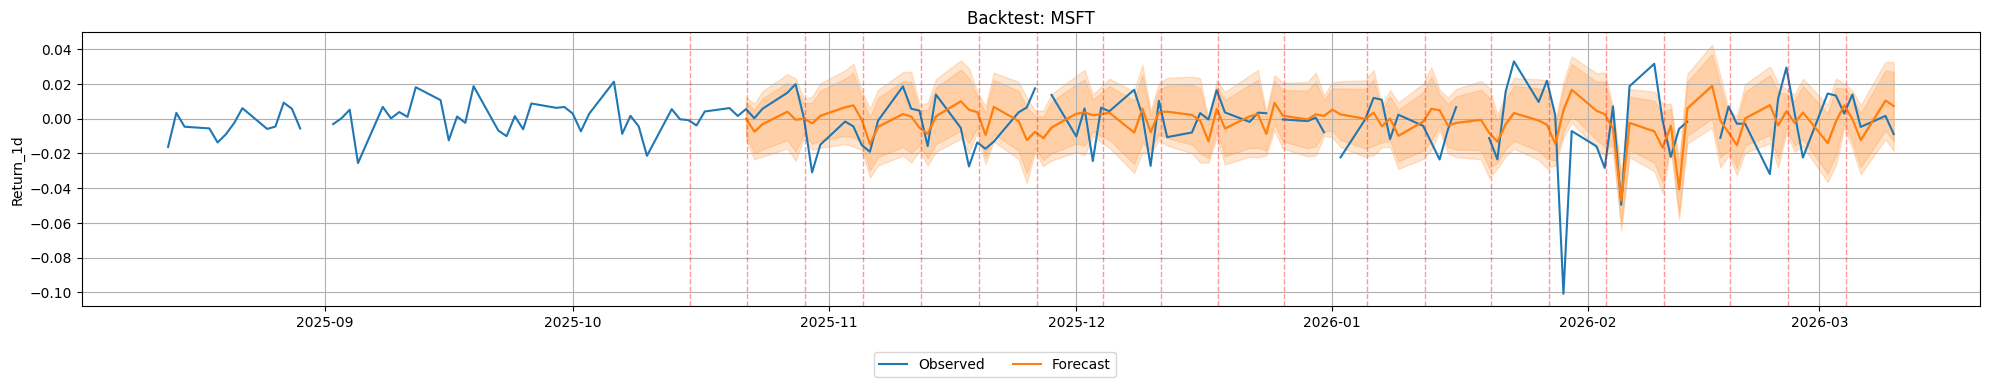

<Figure size 1000x500 with 0 Axes>

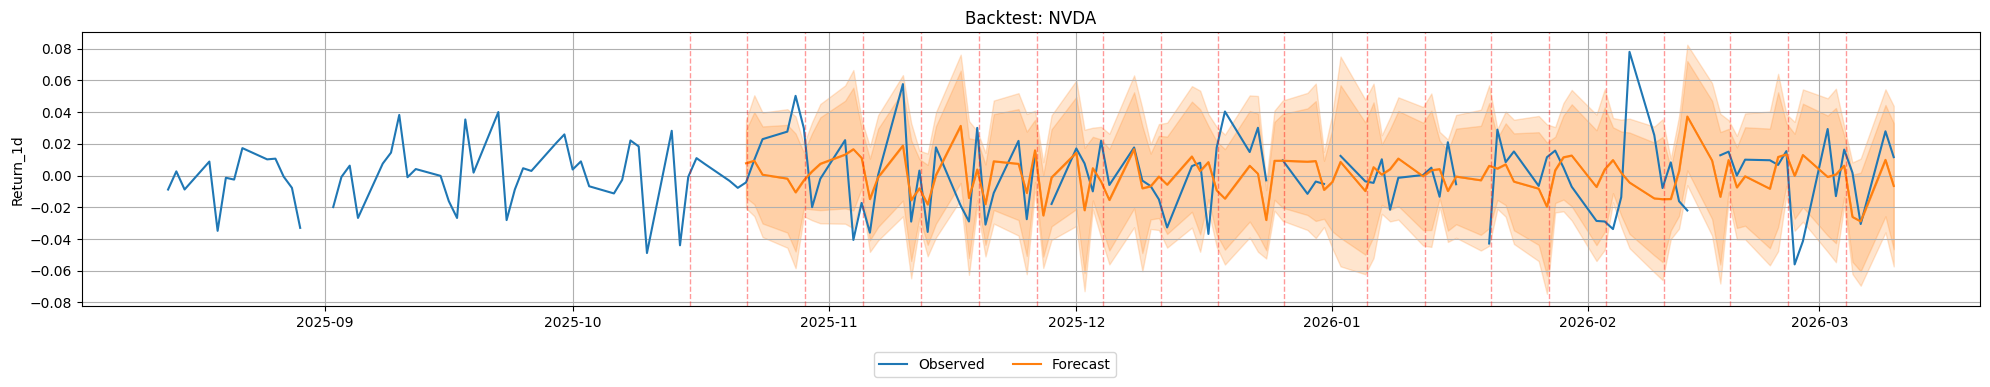

<Figure size 1000x500 with 0 Axes>

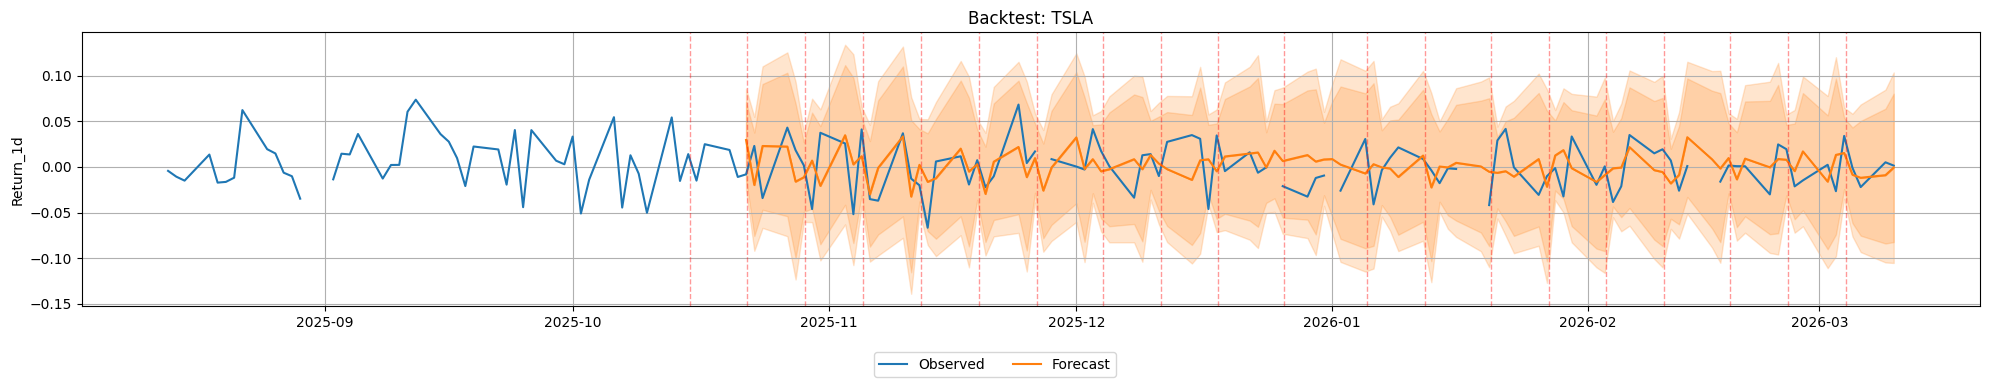

<Figure size 1000x500 with 0 Axes>

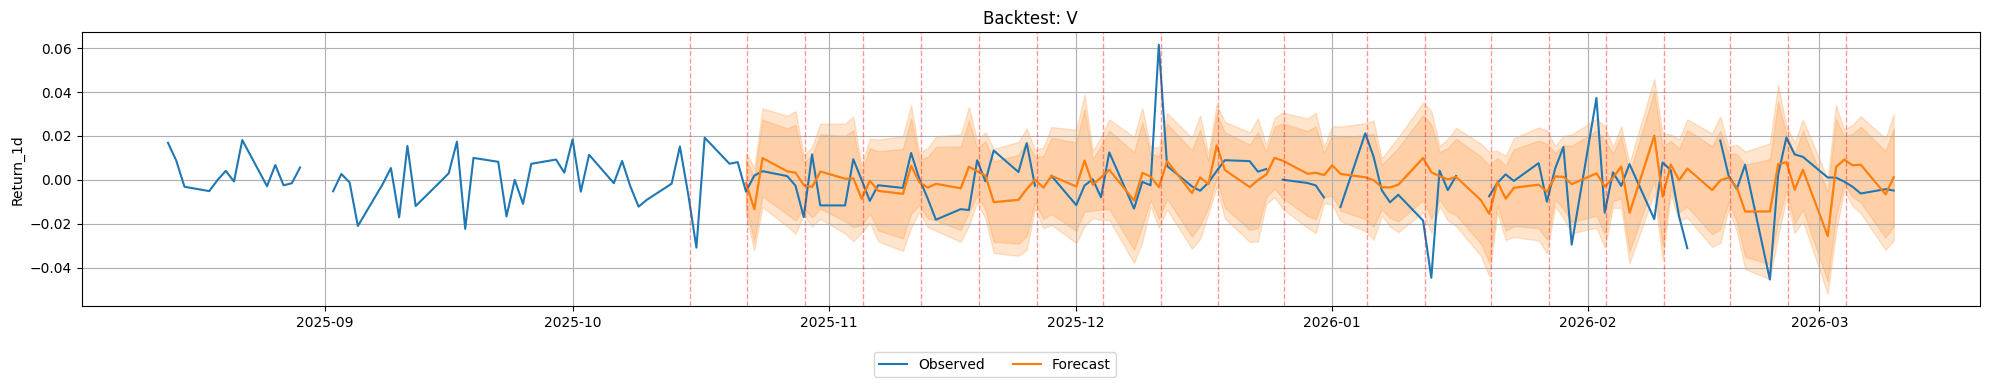

In [ ]:
plot_backtest(predictor, test_data, 5)

In [5]:
fig = plot_interactive_continuous_forecast(predictor, "GOOGL", -0.01)
fig.show()

data with frequency 'IRREG' has been resampled to frequency 'B'.


Dzień: 2026-03-11  | Q(0.05) = -0.024 | Q(0.1) = -0.019 | Q(0.3) = -0.010 | MSG: MONITOR (Q(0.1)-Q(0.3))
Dzień: 2026-03-12  | Q(0.05) = -0.027 | Q(0.1) = -0.020 | Q(0.3) = -0.008 | MSG: MONITOR (Q(0.1)-Q(0.3))
Dzień: 2026-03-13  | Q(0.05) = -0.029 | Q(0.1) = -0.022 | Q(0.3) = -0.009 | MSG: MONITOR (Q(0.1)-Q(0.3))
Dzień: 2026-03-16  | Q(0.05) = -0.026 | Q(0.1) = -0.017 | Q(0.3) = -0.001 | MSG: MONITOR (Q(0.1)-Q(0.3))
Dzień: 2026-03-17  | Q(0.05) = -0.038 | Q(0.1) = -0.031 | Q(0.3) = -0.016 | MSG: HIGH RISK (>Q(0.3))
